In [ ]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import umap

from tsne_spectral import (
    tsne_eigen,
    get_original_pairwise_affinities,
    get_symmetric_p_ij,
    initialization,
    get_low_dimensional_affinities,
    get_gradient,
    spectral_init,
    laplacian_eigenmaps_init,
    load_mnist,
    load_coil20,
    load_olivetti,
    plot_embedding,
)
from UMAP.umap_scratch import UMAP_scratch
from UMAP.umap_custom import UMAP

# Section 6 — Comparative Analysis Across Datasets

**Thesis correspondence:** Section 6

Runs t-SNE with spectral, Laplacian, PCA, and random initialisation on three
datasets — MNIST (500 samples), COIL-20, and Olivetti Faces — and compares:

- Embedding quality with and without gradient descent
- Robustness under pixel-swap perturbations (2 000 swaps per image)
- Daniel's modified kernel: q_{ij} = (1 + ||y_i − y_j||²)^{−1/100}

# Datasets

In [ ]:
x_train_t_pca, y_train_t = load_mnist(n_samples=500, pca_components=40)

In [ ]:
x_train_u_pca, y_train_u = load_mnist(n_samples=5000, pca_components=40)

In [ ]:
coil_path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'
X_pca_coil, y_c = load_coil20(data_dir=coil_path, pca_components=40)

In [ ]:
X_pca_face, y_f = load_olivetti(pca_components=40)

# t-SNE

# Core t-SNE functions imported from tsne_spectral:
# tsne_eigen, get_original_pairwise_affinities, get_symmetric_p_ij,
# initialization, get_low_dimensional_affinities, get_gradient

# UMAP

In [3]:
# Lets import our UMAP function, changing it in other documentation
from UMAP.umap_scratch import UMAP_scratch

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Perturbing Function

In [6]:
def perturb_image(X: np.ndarray, num_invert: int, num_aug: int = 9, seed: int = None) -> np.ndarray:
    """
    Applies pixel swaps between neighboring pixels.
    Returns original images followed by their augmentations,
    grouped per sample: [x0, x0_aug1, ..., x0_aug9, x1, x1_aug1, ..., x1_aug9, ...]
    """
    if seed is not None:
        np.random.seed(seed)

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    if X.ndim == 3:
        n_samples, h, w = X.shape
        channels = None
    elif X.ndim == 4:
        n_samples, h, w, channels = X.shape
    else:
        raise ValueError("Input images must have shape (n_samples, H, W) or (n_samples, H, W, C)")

    all_outputs = []

    for i in range(n_samples):
        base_img = X[i]
        group = [np.copy(base_img)]

        for _ in range(num_aug):
            img = np.copy(base_img)
            for _ in range(num_invert):
                n = np.random.randint(1, h - 1)
                m = np.random.randint(1, w - 1)
                dn, dm = random.choice(directions)
                jn, jm = n + dn, m + dm

                if channels is None:
                    img[n, m], img[jn, jm] = img[jn, jm], img[n, m]
                else:
                    img[n, m, :], img[jn, jm, :] = img[jn, jm, :], img[n, m, :]

            group.append(img)

        all_outputs.extend(group)

    return np.stack(all_outputs)



def show_group_with_labels(X, y, group_index, group_size=10):
    """
    Plot `group_size` images from X[group_index*group_size : (group_index+1)*group_size],
    with their corresponding labels from y just underneath.
    """
    start = group_index * group_size
    images = X[start:start+group_size]
    labels = y[start:start+group_size]

    fig, axes = plt.subplots(2, group_size, figsize=(1.5*group_size, 3), 
                             gridspec_kw={'height_ratios': [4, 1]})
    for i in range(group_size):
        # top row: the image
        ax_img = axes[0, i]
        ax_img.imshow(images[i], cmap='gray')
        ax_img.axis('off')

        # bottom row: the label
        ax_lbl = axes[1, i]
        ax_lbl.text(0.5, 0.5, str(labels[i]),
                    ha='center', va='center', fontsize=12)
        ax_lbl.axis('off')

    plt.tight_layout()
    plt.show()

In [7]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reduce to 200 samples
x_train = x_train[:200]
y_train = y_train[:200]

# Augment images: 4 perturbed versions per original
num_aug = 4
x_train_perturbed = perturb_image(x_train, num_invert=2000, num_aug=num_aug, seed=12)

# Correctly repeat labels for new images:
y_train_perturbed = np.repeat(y_train, 1 + num_aug)  # shape = (100 * 10,)

# Then continue with flatten / scale / PCA...
x_train_perturbed_flat = x_train_perturbed.reshape((x_train_perturbed.shape[0], -1)).astype(np.float32)
scaler = StandardScaler()
x_train_perturbed_scaled = scaler.fit_transform(x_train_perturbed_flat)
pca = PCA(n_components=40)
x_train_perturbed_pca = pca.fit_transform(x_train_perturbed_scaled)

## Eigenmaps of t-SNE

# Core t-SNE + spectral init functions imported from tsne_spectral (see top-level imports)

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 3.710504647411944
Iteration 50: Value of Cost Function is 2.538800224850141
Iteration 100: Value of Cost Function is 2.1447321336570626
Iteration 150: Value of Cost Function is 1.9484955920850229
Iteration 200: Value of Cost Function is 1.8220171518322836
Iteration 250: Value of Cost Function is 1.732291459151358
Iteration 300: Value of Cost Function is 1.663425464181556
Iteration 350: Value of Cost Function is 1.6085278244972667
Iteration 400: Value of Cost Function is 1.5628391856679391
Iteration 450: Value of Cost Function is 1.5240034323266571
Iteration 500: Value of Cost Function is 1.4908189767748738
Iteration 550: V

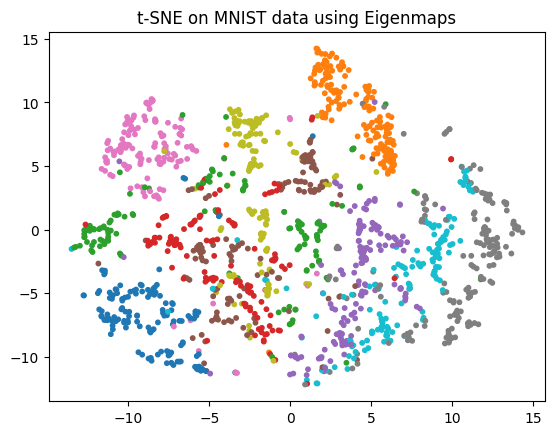

In [90]:
eigenmap = tsne_eigen(x_train_t_pca, initialization_method = 'spectral')

plt.scatter(eigenmap[:, 0], eigenmap[:, 1], c=y_train_t, cmap='tab10', s=10)
plt.title('t-SNE on MNIST data using Eigenmaps')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 3.272388121981003
Iteration 50: Value of Cost Function is 1.8062972067222074
Iteration 100: Value of Cost Function is 1.4545125976807398
Iteration 150: Value of Cost Function is 1.2868312513263522
Iteration 200: Value of Cost Function is 1.181341020293406
Iteration 250: Value of Cost Function is 1.1066871665789197
Iteration 300: Value of Cost Function is 1.049873538627613
Iteration 350: Value of Cost Function is 1.0045721575361732
Iteration 400: Value of Cost Function is 0.9674260642287661
Iteration 450: Value of Cost Function is 0.9362483958636749
Iteration 500: Value of Cost Function is 0.9096185872650375
Iteration 550: 

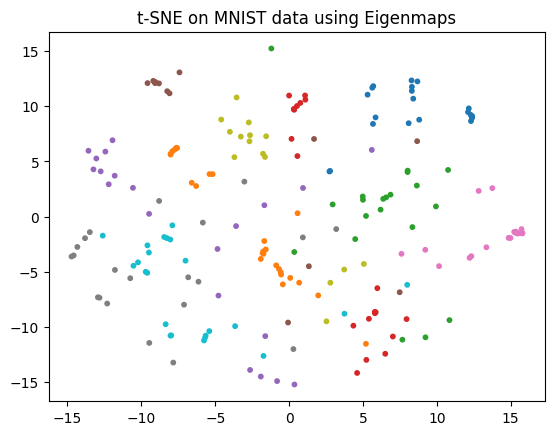

In [10]:
eigenmap_p = tsne_eigen(x_train_perturbed_pca, initialization_method = 'spectral')

plt.scatter(eigenmap_p[::5, 0], eigenmap_p[::5, 1], c=y_train_perturbed[::5], cmap='tab10', s=10)
plt.title('t-SNE on MNIST data using Eigenmaps')
plt.show()

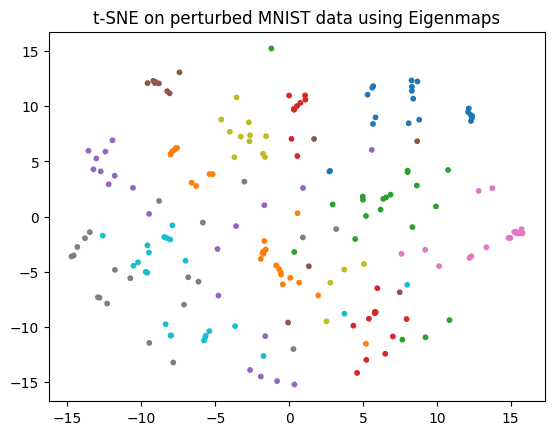

In [11]:
plt.scatter(eigenmap_p[::5, 0], eigenmap_p[::5, 1], c=y_train_perturbed[::5], cmap='tab10', s=10)
plt.title('t-SNE on perturbed MNIST data using Eigenmaps')
plt.show()

## Different swaps and number of creations

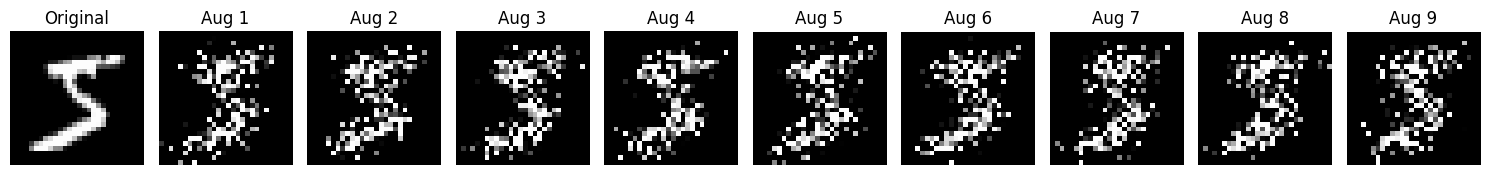

In [12]:
import matplotlib.pyplot as plt

# Pick one digit image to visualize
idx = 0  # index of the image to visualize
num_show = 9  # how many perturbations to display

# Run perturbation only on that one image (repeating it)
sample_image = x_train[idx:idx+1]  # shape (1, 28, 28)
perturbed_samples = perturb_image(sample_image, num_invert=2000, num_aug=num_show, seed=42)

# Plot original + perturbations
fig, axes = plt.subplots(1, num_show + 1, figsize=(15, 2))
axes[0].imshow(sample_image[0], cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(num_show):
    axes[i + 1].imshow(perturbed_samples[i + 1], cmap='gray')  # skip the first (original) image
    axes[i + 1].set_title(f"Aug {i+1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
Y = tsne_eigen(x_train_perturbed_pca)

plt.scatter(Y[::5, 0], Y[::5, 1], c=y_train_perturbed[::5], cmap='tab10', s=10)
plt.title('t-SNE on 2000 swaps and 200 images of MNIST')
plt.show()

## Differences in specral UMAP

In [6]:
model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='reciprocal'
)
umap = model.fit_transform(x_train_u_pca)
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train_u.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP reciprocal')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-20, 20)
plt.ylim(-25, 20)
plt.show()

Wed Jul 23 09:32:57 2025 Finding nearest neighbors
Wed Jul 23 09:32:57 2025 Finding Nearest Neighbors
Wed Jul 23 09:32:57 2025 Building RP forest with 12 trees
Wed Jul 23 09:33:03 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Wed Jul 23 09:33:15 2025 Finished Nearest Neighbor Search
Wed Jul 23 09:33:15 2025 Computing fuzzy simplicial set
Wed Jul 23 09:33:31 2025 Initializing embedding


  0%|          | 0/1000 [00:00<?, ?it/s]


TypeError: not enough arguments: expected 28, got 27

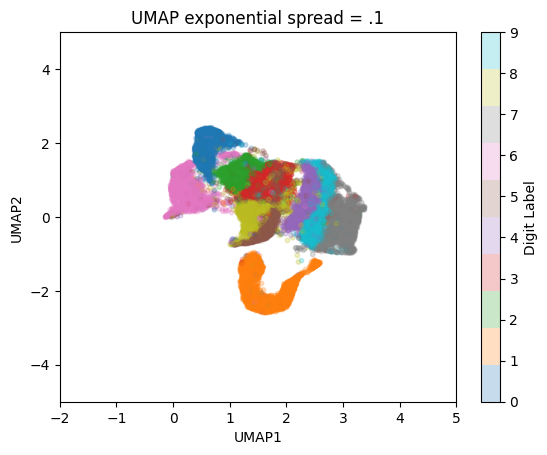

In [53]:
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train_u.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP exponential spread = .1')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-2, 5)
plt.ylim(-5, 5)
plt.show()

# t-SNE for Daniel

In [ ]:
def get_low_dimensional_affinities_d(Y: np.ndarray) -> np.ndarray:
    """Low-dim affinities using Daniel's kernel: q_ij = (1 + ||y_i - y_j||²)^{-1/100}."""
    n = len(Y)
    q_ij = np.zeros(shape=(n, n))
    for i in range(n):
        diff = Y[i] - Y
        norm = np.linalg.norm(diff, axis=1)
        q_ij[i, :] = (1 + norm**2) ** (-1 / 100)
    np.fill_diagonal(q_ij, 0)
    q_ij = q_ij / q_ij.sum()
    epsilon = np.nextafter(0, 1)
    return np.maximum(q_ij, epsilon)


def get_gradient_d(p_ij: np.ndarray, q_ij: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Gradient for Daniel's modified kernel."""
    n = len(p_ij)
    gradient = np.zeros(shape=(n, Y.shape[1]))
    for i in range(n):
        diff = Y[i] - Y
        A = np.array([(p_ij[i, :] - q_ij[i, :])])
        B = np.array(1.0 / (100 * (1.0 + np.linalg.norm(diff, axis=1) ** 2)))
        gradient[i] = 4 * np.sum((A * B).T * diff, axis=0)
    return gradient


def tsne_daniel(
    X: np.ndarray,
    perplexity: int = 30,
    T: int = 1000,
    eta: int = 100,
    early_exaggeration: int = 1,
    n_dimensions: int = 2,
) -> np.ndarray:
    n = len(X)
    p_ij = get_original_pairwise_affinities(X, perplexity)
    p_ij_symmetric = get_symmetric_p_ij(p_ij)

    Y = np.zeros(shape=(T, n, n_dimensions))
    Y[0] = np.zeros(shape=(n, n_dimensions))
    Y[1] = initialization(X, n_dimensions)

    print("Optimizing Low Dimensional Embedding....")
    for t in range(1, T - 1):
        exagg = early_exaggeration if t < 250 else 1
        q_ij = get_low_dimensional_affinities_d(Y[t])
        gradient = get_gradient_d(exagg * p_ij_symmetric, q_ij, Y[t])
        Y[t + 1] = Y[t] - eta * gradient
        if t % 50 == 0 or t == 1:
            cost = np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))
            print(f"Iteration {t}: Cost = {cost:.4f}")

    print(f"Final Cost = {np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij)):.4f}")
    return Y[-1]

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.6541172743674764
Iteration 50: Value of Cost Function is 1.6536406103855943
Iteration 100: Value of Cost Function is 1.653169869032007
Iteration 150: Value of Cost Function is 1.6527187731447128
Iteration 200: Value of Cost Function is 1.6522921067117797
Iteration 250: Value of Cost Function is 1.6518954922942974
Iteration 300: Value of Cost Function is 1.6515342248540783
Iteration 350: Value of Cost Function is 1.651211353202758
Iteration 400: Value of Cost Function is 1.6509254574522265
Iteration 450: Value of Cost Function is 1.6506655466538038
Iteration 500: Value of Cost Function is 1.650423191976551
Iteration 550: Value of Cost Function is 1.6501976704354429
Iteration 600: Value of Cost Function is 1.6499891368140798
Iteration 650: Value of Cost Function is

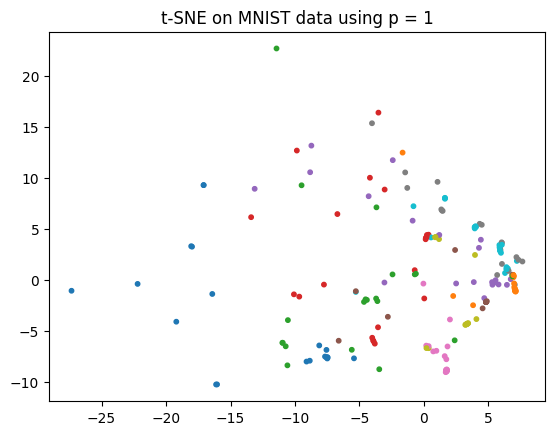

In [16]:
# Example usage of Daniel new beta function
daniel = tsne_daniel(x_train_t_pca)

plt.scatter(daniel[:, 0], daniel[:, 1], c=y_train_t, cmap='tab10', s=10)
plt.title('t-SNE on MNIST data using p = 1')
plt.show()

In [ ]:
normal = tsne_eigen(x_train_t_pca)

plt.scatter(normal[:, 0], normal[:, 1], c=y_train_t, cmap='tab10', s=10)
plt.title('t-SNE on MNIST data')
plt.show()

# UMAP custom Spectral layout

Wed Jul 30 10:04:50 2025 Finding nearest neighbors
Wed Jul 30 10:04:50 2025 Finding Nearest Neighbors
Wed Jul 30 10:04:50 2025 Building RP forest with 12 trees
Wed Jul 30 10:04:50 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Wed Jul 30 10:04:51 2025 Finished Nearest Neighbor Search
Wed Jul 30 10:04:51 2025 Computing fuzzy simplicial set
Wed Jul 30 10:05:37 2025 Initializing embedding


  1%|          | 8/1000 [00:00<01:00, 16.41it/s]

	completed  0  /  1000 epochs


 10%|█         | 102/1000 [00:10<01:28, 10.09it/s]

	completed  100  /  1000 epochs


...

 80%|████████  | 801/1000 [02:11<00:41,  4.82it/s]

	completed  800  /  1000 epochs


 90%|█████████ | 901/1000 [02:31<00:19,  5.14it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [02:51<00:00,  5.84it/s]


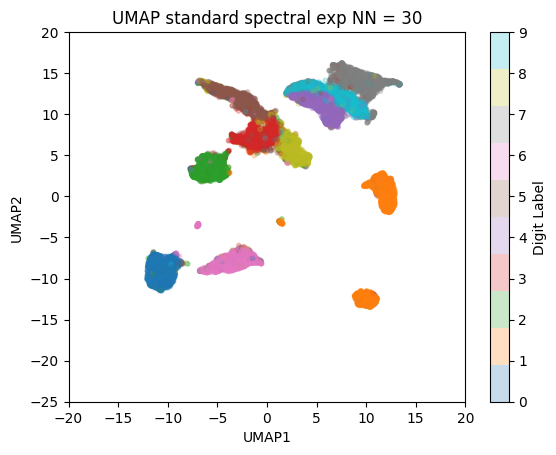

In [5]:
model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='exp'
)
umap = model.fit_transform(x_train_u_pca)
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train_u.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP standard spectral exp NN = 30')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-20, 20)
plt.ylim(-25, 20)
plt.show()

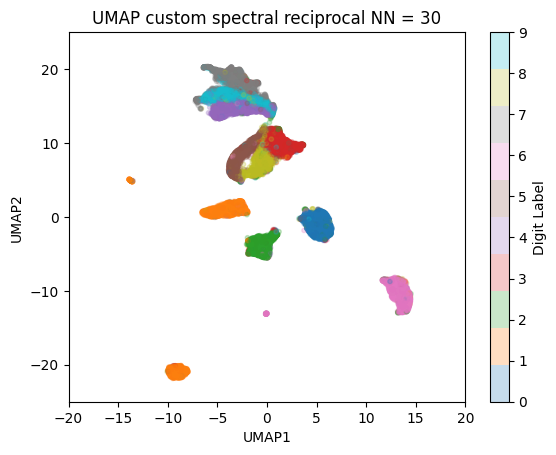

In [10]:
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train_u.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP custom spectral reciprocal NN = 30')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-20, 20)
plt.ylim(-25, 25)
plt.show()

# Original UMAP

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


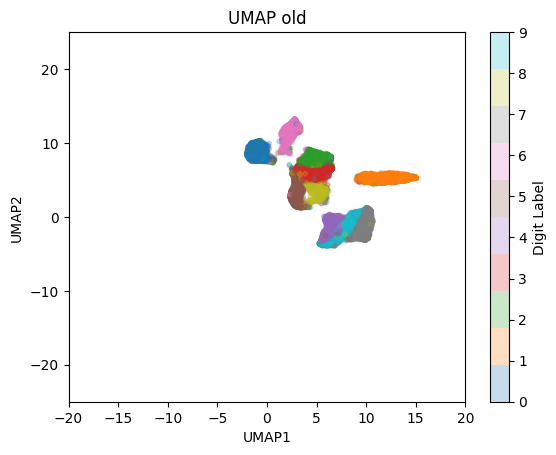

In [ ]:
import umap

reducer = umap.UMAP(
    n_neighbors=50,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=.1,
    spread=1.0,
    random_state=42,
    verbose=False
)
old = reducer.fit_transform(x_train_u_pca)

scatter = plt.scatter(old[:, 0], old[:, 1], c=y_train_u.astype(int), cmap="tab10", s=10, alpha=0.25)
plt.title("UMAP old")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label="Digit Label")
plt.show()


## trying a spectral graph that uses p_ij

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\UMAP\umap_custom.py:2018: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


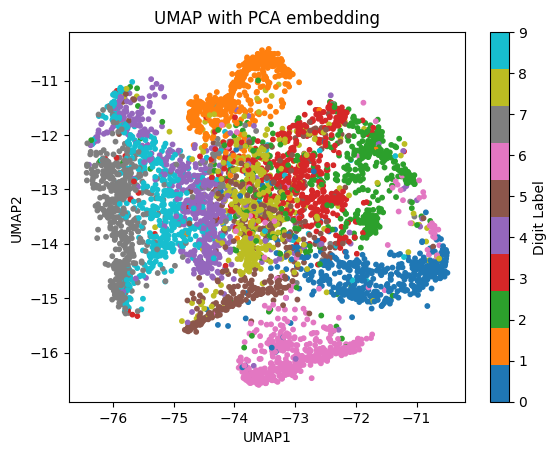

In [8]:
from UMAP.umap_custom import UMAP

reducer = UMAP(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="pca",
    min_dist=.01,
    spread=1.0,
    random_state=42,
    verbose=False
)
old = reducer.fit_transform(x_train_u_pca)

scatter = plt.scatter(old[:, 0], old[:, 1], c=y_train_u.astype(int), cmap="tab10", s=10, alpha=1.0)
plt.title("UMAP with PCA embedding")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label="Digit Label")
plt.show()

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\UMAP\umap_custom.py:2018: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


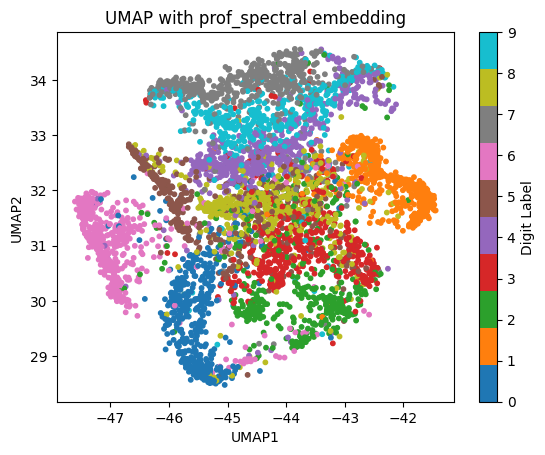

In [11]:
from UMAP.umap_custom import UMAP

reducer = UMAP(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="prof_spectral",
    min_dist=.01,
    spread=1.0,
    random_state=42,
    verbose=False
)
old = reducer.fit_transform(x_train_u_pca)

scatter = plt.scatter(old[:, 0], old[:, 1], c=y_train_u.astype(int), cmap="tab10", s=10, alpha=1.0)
plt.title("UMAP with prof_spectral embedding")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label="Digit Label")
plt.show()

## Spectral p_ij in UMAP_scratch

Wed Aug 20 09:11:02 2025 Finding nearest neighbors
Wed Aug 20 09:11:02 2025 Finding Nearest Neighbors
Wed Aug 20 09:11:02 2025 Building RP forest with 9 trees
Wed Aug 20 09:11:03 2025 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Wed Aug 20 09:11:03 2025 Finished Nearest Neighbor Search
Wed Aug 20 09:11:03 2025 Computing fuzzy simplicial set
Wed Aug 20 09:11:07 2025 Initializing embedding
Wed Aug 20 09:11:07 2025 Finding Nearest Neighbors
Wed Aug 20 09:11:07 2025 Building RP forest with 9 trees
Wed Aug 20 09:11:07 2025 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Wed Aug 20 09:11:07 2025 Finished Nearest Neighbor Search
[init] C≈ 150732.1613


  1%|          | 11/1000 [00:00<00:10, 97.64it/s]

	completed  0  /  1000 epochs


 12%|█▏        | 117/1000 [00:01<00:12, 68.40it/s]

	completed  100  /  1000 epochs


...

	completed  800  /  1000 epochs


 92%|█████████▏| 915/1000 [00:13<00:01, 68.52it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:14<00:00, 67.87it/s]


[final] C≈ 45657.6911


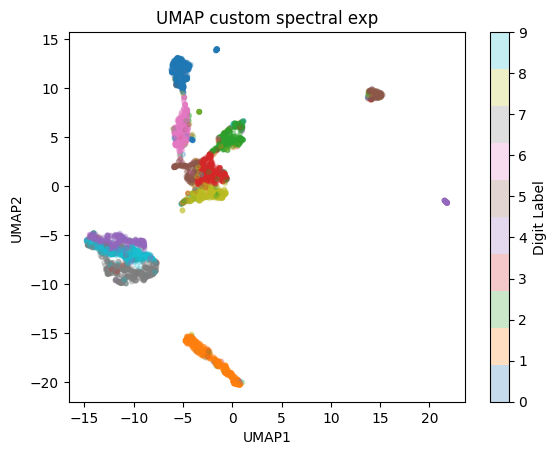

In [31]:
import importlib, UMAP.umap_scratch as umap_scratch
importlib.reload(umap_scratch)
from UMAP.umap_scratch import UMAP_scratch


Y = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="prof_spectral",
    min_dist=.01,
    spread=1.0,
    random_state=42,
    verbose=True,
    init_topk=30,
    similarity='exp'
    )

new_umap = Y.fit_transform(x_train_u_pca)

scatter = plt.scatter(new_umap[:, 0], new_umap[:, 1], c=y_train_u.astype(int), cmap="tab10", s=10, alpha = .25)
plt.title("UMAP custom spectral exp")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label="Digit Label")
#plt.xlim(-20,20)
#plt.ylim(-20,25)
plt.show()

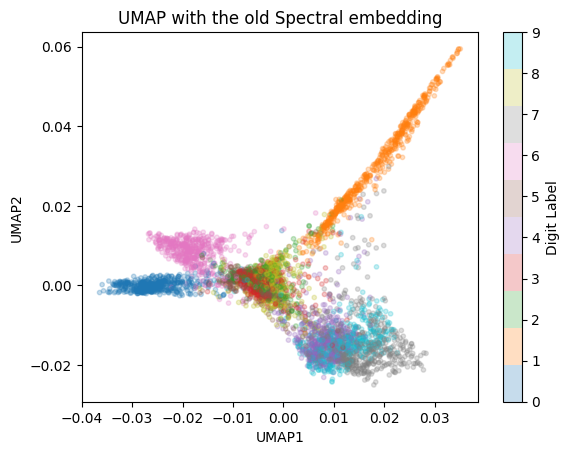

In [36]:
from UMAP.umap_scratch import UMAP_scratch

Y = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=0,
    learning_rate=1.0,
    init="spectral",
    min_dist=.01,
    spread=1.0,
    random_state=42,
    verbose=False,
    init_topk = 30,
    similarity = 'reciprocal'
    )

new_umap = Y.fit_transform(x_train_u_pca)

scatter = plt.scatter(new_umap[:, 0], new_umap[:, 1], c=y_train_u.astype(int), cmap="tab10", s=10, alpha=.25)
plt.title("UMAP with the old Spectral embedding")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label="Digit Label")
#plt.xlim(-20, 20)
#plt.ylim(-20, 20)
plt.show()

Thu Aug 14 23:24:46 2025 Finding nearest neighbors
Thu Aug 14 23:24:46 2025 Finding Nearest Neighbors
Thu Aug 14 23:24:46 2025 Building RP forest with 7 trees
Thu Aug 14 23:24:46 2025 NN descent for 10 iterations
	 1  /  10
	 2  /  10
	 3  /  10
	Stopping threshold met -- exiting after 3 iterations
Thu Aug 14 23:24:46 2025 Finished Nearest Neighbor Search
Thu Aug 14 23:24:46 2025 Computing fuzzy simplicial set
Thu Aug 14 23:24:48 2025 Initializing embedding
Thu Aug 14 23:24:48 2025 Finding Nearest Neighbors
Thu Aug 14 23:24:48 2025 Building RP forest with 7 trees
Thu Aug 14 23:24:48 2025 NN descent for 10 iterations
	 1  /  10
	 2  /  10
	 3  /  10
	Stopping threshold met -- exiting after 3 iterations
Thu Aug 14 23:24:48 2025 Finished Nearest Neighbor Search
[init] warning: 116 zero-degree nodes in kNN graph (try raising n_neighbors/init_topk).


  3%|▎         | 28/1000 [00:00<00:03, 274.04it/s]

	completed  0  /  1000 epochs


 14%|█▎        | 137/1000 [00:00<00:03, 259.73it/s]

	completed  100  /  1000 epochs


...

 85%|████████▍ | 847/1000 [00:03<00:00, 255.14it/s]

	completed  800  /  1000 epochs


 93%|█████████▎| 927/1000 [00:03<00:00, 258.35it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:04<00:00, 249.95it/s]


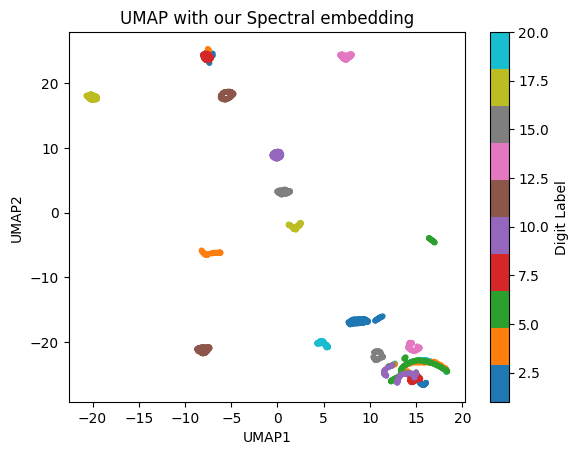

In [28]:
from UMAP.umap_scratch import UMAP_scratch

Y = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="prof_spectral",
    min_dist=.01,
    spread=1.0,
    random_state=42,
    verbose=True,
    init_topk = 90
    )

new_umap = Y.fit_transform(X_pca_coil)

scatter = plt.scatter(new_umap[:, 0], new_umap[:, 1], c=y_c.astype(int), cmap="tab10", s=10)
plt.title("UMAP with our Spectral embedding")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label="Digit Label")
plt.show()

[init] warning: 386 zero-degree nodes in kNN graph (try raising n_neighbors/init_topk).


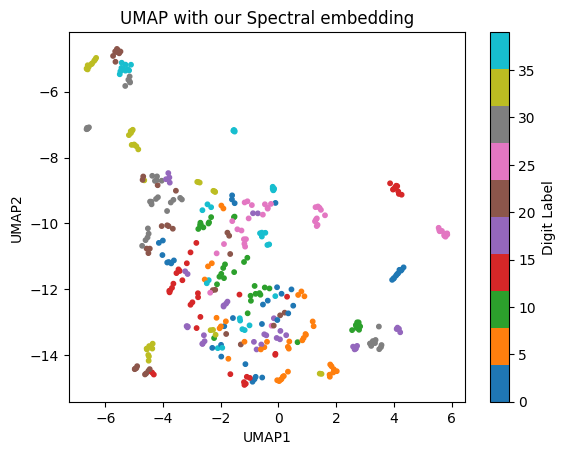

In [31]:
from UMAP.umap_scratch import UMAP_scratch

Y = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="prof_spectral",
    min_dist=.01,
    spread=1.0,
    random_state=42,
    verbose=False,
    init_topk = 90
    )

new_umap = Y.fit_transform(X_pca_face)

scatter = plt.scatter(new_umap[:, 0], new_umap[:, 1], c=y_f.astype(int), cmap="tab10", s=10)
plt.title("UMAP with our Spectral embedding")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label="Digit Label")
plt.show()